In [39]:
# Import library dasar
import os
import re
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Import library Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility (Mengunci Seed)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Menyiapkan list untuk menyimpan hasil perbandingan model
results = []
print("Setup selesai. Random Seed telah dikunci.")

Setup selesai. Random Seed telah dikunci.


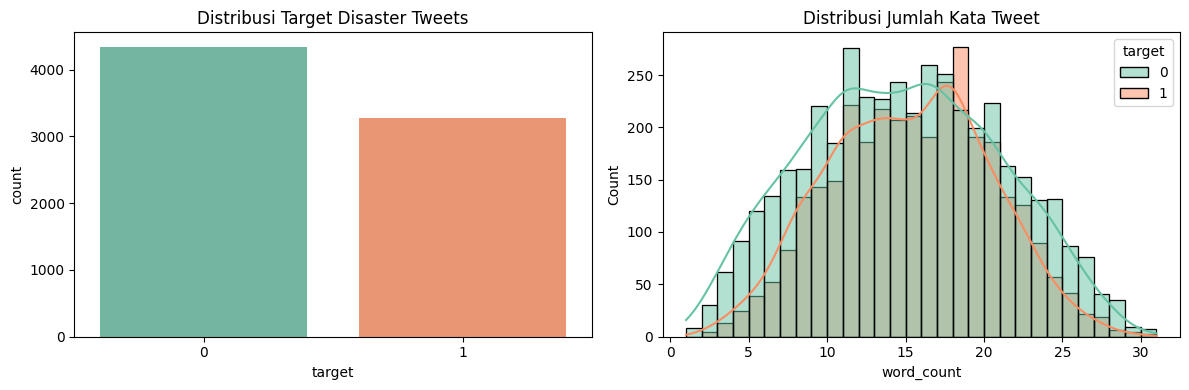

In [40]:
# Load Dataset
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# --- EDA Wajib ---
df_train["text_length"] = df_train["text"].astype(str).apply(len)
df_train["word_count"] = df_train["text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 4))

# Grafik 1: Distribusi Target
plt.subplot(1, 2, 1)
sns.countplot(data=df_train, x="target", palette="Set2")
plt.title("Distribusi Target Disaster Tweets")

# Grafik 2: Distribusi Jumlah Kata
plt.subplot(1, 2, 2)
sns.histplot(data=df_train, x="word_count", hue="target", bins=30, kde=True, palette="Set2")
plt.title("Distribusi Jumlah Kata Tweet")

plt.tight_layout()
plt.show()

In [41]:
# Fungsi Pembersihan Teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text) # Hapus URL
    text = re.sub(r"@\w+", " ", text) # Hapus mention
    text = re.sub(r"#", "", text) # Hapus simbol hashtag, biarkan teksnya
    text = re.sub(r"&amp;|&lt;|&gt;", " ", text) # Hapus entitas HTML
    text = re.sub(r"[^a-zA-Z\s]", " ", text) # Hapus karakter non-alfabet
    text = re.sub(r"\s+", " ", text).strip() # Hapus spasi berlebih
    return text

# Mengaplikasikan fungsi pembersihan
df_train["clean_text"] = df_train["text"].apply(clean_text)
df_test["clean_text"] = df_test["text"].apply(clean_text)

# Memisahkan Fitur dan Target (Train-Validation Split)
X = df_train["clean_text"]
y = df_train["target"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"Data latih: {X_train.shape[0]} tweet | Data validasi: {X_val.shape[0]} tweet")

Data latih: 6090 tweet | Data validasi: 1523 tweet


In [42]:
# Fungsi untuk melatih dan mengevaluasi model agar rapi
def evaluate_text_model(model_name, model, X_train, y_train, X_val, y_val):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_infer = time.time()
    y_pred = model.predict(X_val)
    infer_time = time.time() - start_infer

    f1 = f1_score(y_val, y_pred)

    print(f"===== {model_name} =====")
    print(f"F1-score Validasi : {f1:.4f}")
    print(f"Waktu Training    : {train_time:.4f} detik")
    print(f"Waktu Inferensi   : {infer_time:.4f} detik\n")

    results.append({
        "Model": model_name,
        "F1-score": f1,
        "Train Time": train_time,
        "Inference Time": infer_time
    })
    return y_pred

In [43]:
# Baseline 1: TF-IDF Unigram + Logistic Regression
tfidf_logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 1), max_features=10000, min_df=2, max_df=0.9)),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])
y_pred_logreg = evaluate_text_model("TF-IDF Unigram + LogReg", tfidf_logreg_model, X_train, y_train, X_val, y_val)

# Baseline 2: TF-IDF Unigram+Bigram + Linear SVM
tfidf_svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=2, max_df=0.9)),
    ("clf", LinearSVC(C=1.0, random_state=SEED, max_iter=5000))
])
y_pred_svm = evaluate_text_model("TF-IDF Bigram + LinearSVM", tfidf_svm_model, X_train, y_train, X_val, y_val)

===== TF-IDF Unigram + LogReg =====
F1-score Validasi : 0.7727
Waktu Training    : 0.1327 detik
Waktu Inferensi   : 0.0375 detik

===== TF-IDF Bigram + LinearSVM =====
F1-score Validasi : 0.7643
Waktu Training    : 0.3847 detik
Waktu Inferensi   : 0.0384 detik



In [44]:
MAX_WORDS = 20000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Tokenizing dan Padding untuk Train, Validation, dan Test
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(df_test["clean_text"]), maxlen=MAX_LEN, padding="post", truncating="post")

print("Dimensi data Deep Learning (X_train_pad):", X_train_pad.shape)

Dimensi data Deep Learning (X_train_pad): (6090, 40)


In [45]:
# Membangun Model BiLSTM
bilstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Training Model
print("Memulai Training BiLSTM...")
start_train = time.time()
history = bilstm_model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                           epochs=10, batch_size=32, callbacks=[early_stop], verbose=1)
bilstm_train_time = time.time() - start_train

# Evaluasi Model
start_infer = time.time()
y_pred_prob_bilstm = bilstm_model.predict(X_val_pad)
bilstm_infer_time = time.time() - start_infer

y_pred_bilstm = (y_pred_prob_bilstm >= 0.5).astype(int).ravel()
bilstm_f1 = f1_score(y_val, y_pred_bilstm)

print(f"\n===== Embedding + BiLSTM =====")
print(f"F1-score Validasi : {bilstm_f1:.4f}")

results.append({
    "Model": "Embedding + BiLSTM",
    "F1-score": bilstm_f1,
    "Train Time": bilstm_train_time,
    "Inference Time": bilstm_infer_time
})

Memulai Training BiLSTM...
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.6900 - loss: 0.5754 - val_accuracy: 0.8102 - val_loss: 0.4372
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.8606 - loss: 0.3402 - val_accuracy: 0.7899 - val_loss: 0.5088
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.9182 - loss: 0.2155 - val_accuracy: 0.7833 - val_loss: 0.5890
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.9524 - loss: 0.1353 - val_accuracy: 0.7623 - val_loss: 0.7508
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

===== Embedding + BiLSTM =====
F1-score Validasi : 0.7712


In [46]:
# --- Komparasi Waktu dan Metrik ---
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
print("=== TABEL PERBANDINGAN MODEL ===")
display(results_df)

# --- Analisis Error (Sesuai Arahan 4) ---
error_df = pd.DataFrame({
    "text_asli": X_val.values,
    "actual_label": y_val.values,
    "pred_svm": y_pred_svm,
    "pred_bilstm": y_pred_bilstm
})

# Kasus dimana SVM (Konvensional) salah, tapi BiLSTM (Deep Learning) benar
bilstm_correct_svm_wrong = error_df[(error_df["actual_label"] == error_df["pred_bilstm"]) & (error_df["actual_label"] != error_df["pred_svm"])]

print("\n--- Contoh Tweet yang SVM SALAH, namun BiLSTM BENAR ---")
for idx, row in bilstm_correct_svm_wrong.head(3).iterrows():
    print(f"Teks: {row['text_asli']}")
    print(f"Label Asli: {row['actual_label']} | Prediksi BiLSTM: {row['pred_bilstm']} | Prediksi SVM: {row['pred_svm']}\n")

=== TABEL PERBANDINGAN MODEL ===


,Model,F1-score,Train Time,Inference Time
0,TF-IDF Unigram + LogReg,0.772652,0.132653,0.037486
2,Embedding + BiLSTM,0.771180,138.117638,2.602852
1,TF-IDF Bigram + LinearSVM,0.764341,0.384742,0.038433



--- Contoh Tweet yang SVM SALAH, namun BiLSTM BENAR ---
Teks: rip the world its burning
Label Asli: 0 | Prediksi BiLSTM: 0 | Prediksi SVM: 1

Teks: where did you get that pic from where it shows that there is trophies for outbreak or did they photoshop it
Label Asli: 0 | Prediksi BiLSTM: 0 | Prediksi SVM: 1

Teks: ignition knock detonation sensor senso standard ks
Label Asli: 0 | Prediksi BiLSTM: 0 | Prediksi SVM: 1

